# Problem Definition
Loan default poses a significant risk to financial institutions, affecting profitability and overall financial stability. Identifying high-risk borrowers is therefore critical for effective credit risk management.

This project focuses on preparing a loan dataset for predictive modeling by cleaning and structuring the data to ensure quality and consistency. The cleaned dataset will be used to support the development of a machine learning model aimed at predicting the likelihood of loan default based on borrower characteristics and loan attributes

# Importing Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Understanding

The dataset was loaded, and column names were converted to lowercase for consistency. Key variables were renamed for clarity, with ltv and dtir1 converted to loan_to_value and debt_to_income, respectively. The ID column was set as the index to identify records uniquely. The year column was removed as it contained only a single value (2019) and did not contribute to the analysis.



In [3]:
# Load Data
loans_df = pd.read_csv("C:/Users/Rasheedat/Downloads/Loan_Default.csv", index_col = 'ID', dtype = {'ID': str})

# Clean column names
loans_df.columns = loans_df.columns.str.lower()
loans_df = loans_df.rename(columns={
    'ltv': 'loan_to_value',
    'dtir1': 'debt_to_income'
})

loans_df = loans_df.drop(columns=['year'])

In [4]:
loans_df.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,loan_to_value,region,security_type,status,debt_to_income
ID,,,,,,,,,,,,,,,,,,,,,
24890,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
24891,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
24892,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
24893,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
24894,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
loans_df.tail()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,loan_to_value,region,security_type,status,debt_to_income
ID,,,,,,,,,,,,,,,,,,,,,
173555,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.125,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
173556,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.190,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
173557,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.125,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
173558,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.500,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
173559,cf,Female,nopre,type1,p3,l1,nopc,nob/c,406500,4.375,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [6]:
loans_df.shape

(148670, 32)

In [7]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148670 entries, 24890 to 173559
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  object 
 1   gender                     148670 non-null  object 
 2   approv_in_adv              147762 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148536 non-null  object 
 5   credit_worthiness          148670 non-null  object 
 6   open_credit                148670 non-null  object 
 7   business_or_commercial     148670 non-null  object 
 8   loan_amount                148670 non-null  int64  
 9   rate_of_interest           112231 non-null  float64
 10  interest_rate_spread       112031 non-null  float64
 11  upfront_charges            109028 non-null  float64
 12  term                       148629 non-null  float64
 13  neg_ammortization          148

In [8]:
loans_df.describe()

,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,loan_to_value,status,debt_to_income
count,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [9]:
cat_cols = loans_df.select_dtypes(include='object').columns
loans_df[cat_cols].nunique()

loan_limit                   2
gender                       4
approv_in_adv                2
loan_type                    3
loan_purpose                 4
credit_worthiness            2
open_credit                  2
business_or_commercial       2
neg_ammortization            2
interest_only                2
lump_sum_payment             2
construction_type            2
occupancy_type               3
secured_by                   2
total_units                  4
credit_type                  4
co-applicant_credit_type     2
age                          7
submission_of_application    2
region                       4
security_type                2
dtype: int64

# Data Cleaning

Missing values were first assessed both in absolute terms and as percentages to understand their distribution across the dataset.

For numerical variables, missing values were imputed using the median. This approach was chosen due to the presence of skewed distributions and potential outliers, making the median a more robust measure of central tendency compared to the mean.

For categorical variables, missing values were filled using the mode, as it represents the most frequent category and preserves the overall distribution of the data.

After imputation, missing values were re-evaluated and confirmed to be fully resolved (0 missing across all columns). Summary statistics were then recomputed using describe(), showing more consistent and reliable summary statistics across the dataset.

This approach ensures that missing data are handled to maintain the integrity of the dataset while minimizing distortion.



In [10]:
loans_df.isnull().sum()

loan_limit                    3344
gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
credit_worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
interest_rate_spread         36639
upfront_charges              39642
term                            41
neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
secured_by                       0
total_units                      0
income                        9150
credit_type                      0
credit_score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
loan_to_value                15098
region              

In [11]:
(loans_df.isnull().sum() / len(loans_df)) * 100

loan_limit                    2.249277
gender                        0.000000
approv_in_adv                 0.610749
loan_type                     0.000000
loan_purpose                  0.090133
credit_worthiness             0.000000
open_credit                   0.000000
business_or_commercial        0.000000
loan_amount                   0.000000
rate_of_interest             24.509989
interest_rate_spread         24.644515
upfront_charges              26.664425
term                          0.027578
neg_ammortization             0.081388
interest_only                 0.000000
lump_sum_payment              0.000000
property_value               10.155378
construction_type             0.000000
occupancy_type                0.000000
secured_by                    0.000000
total_units                   0.000000
income                        6.154571
credit_type                   0.000000
credit_score                  0.000000
co-applicant_credit_type      0.000000
age                      

In [12]:
loans_df['property_value'] = loans_df.groupby('occupancy_type')['property_value']\
    .transform(lambda x: x.fillna(x.median()))

In [13]:
loans_df['rate_of_interest'] = loans_df.groupby(['loan_type', 'credit_worthiness'])['rate_of_interest']\
    .transform(lambda x: x.fillna(x.median()))

In [14]:
loans_df['loan_to_value'] = loans_df['loan_to_value'].fillna(
    loans_df['loan_amount'] / loans_df['property_value']
)

In [15]:
loans_df['income'] = loans_df.groupby(['age', 'region'])['income']\
    .transform(lambda x: x.fillna(x.median()))

loans_df['income'] = loans_df['income'].fillna(loans_df['income'].median())

In [16]:
loans_df['debt_to_income'] = loans_df.groupby('credit_worthiness')['debt_to_income']\
    .transform(lambda x: x.fillna(x.median()))

In [17]:
loans_df['loan_limit'] = loans_df.groupby(['loan_type', 'credit_worthiness'])['loan_limit']\
    .transform(lambda x: x.fillna(x.mode()[0]))

In [18]:
loans_df['interest_rate_spread'] = loans_df.groupby(
    ['loan_type', 'credit_worthiness']
)['interest_rate_spread'].transform(lambda x: x.fillna(x.median()))

In [19]:
loans_df['upfront_charges'] = loans_df.groupby(
    ['loan_type', 'loan_purpose']
)['upfront_charges'].transform(lambda x: x.fillna(x.median()))

loans_df['upfront_charges'] = loans_df['upfront_charges'].fillna(
    loans_df['upfront_charges'].median()
)

In [20]:
loans_df['approv_in_adv'] = loans_df['approv_in_adv'].fillna(
    loans_df['approv_in_adv'].mode()[0]
)

In [21]:
loans_df['loan_purpose'] = loans_df['loan_purpose'].fillna(
    loans_df['loan_purpose'].mode()[0]
)

In [22]:
loans_df['term'] = loans_df['term'].fillna(
    loans_df['term'].mode()[0]
)

In [23]:
loans_df['neg_ammortization'] = loans_df['neg_ammortization'].fillna(
    loans_df['neg_ammortization'].mode()[0]
)

In [24]:
loans_df['age'] = loans_df['age'].fillna(
    loans_df['age'].mode()[0]
)

In [25]:
loans_df['submission_of_application'] = loans_df['submission_of_application'].fillna(
    loans_df['submission_of_application'].mode()[0]
)

In [26]:
loans_df.isnull().sum()

loan_limit                   0
gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
interest_rate_spread         0
upfront_charges              0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
secured_by                   0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
loan_to_value                0
region                       0
security_type                0
status                       0
debt_to_income               0
dtype: i

# Outlier
Numerical features were selected for outlier detection, excluding status (a binary target variable) and term (a discrete variable treated as categorical). The IQR method was applied to identify outliers, and boxplots were used to visualize their distribution across each feature

Although outliers were identified, no treatment was applied, as extreme values in financial data often reflect genuine high-risk or high-value cases rather than anomalies

loan_amount: 1895 outliers


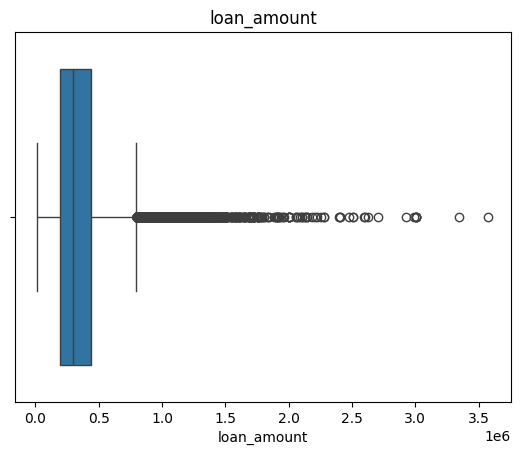

rate_of_interest: 6817 outliers


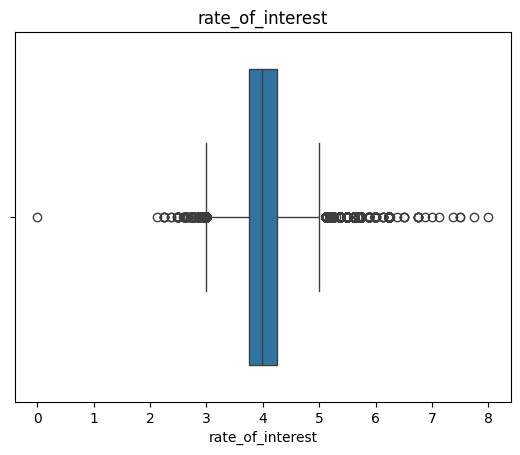

interest_rate_spread: 1662 outliers


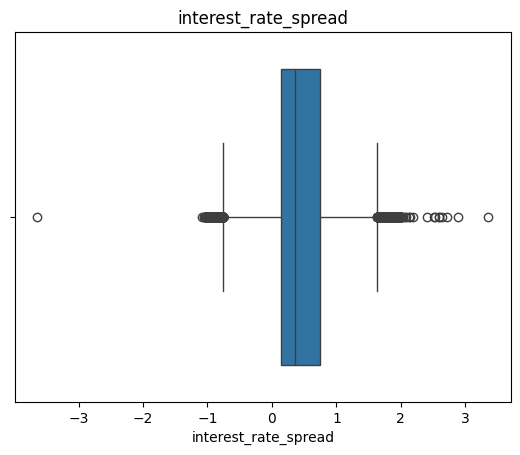

upfront_charges: 7535 outliers


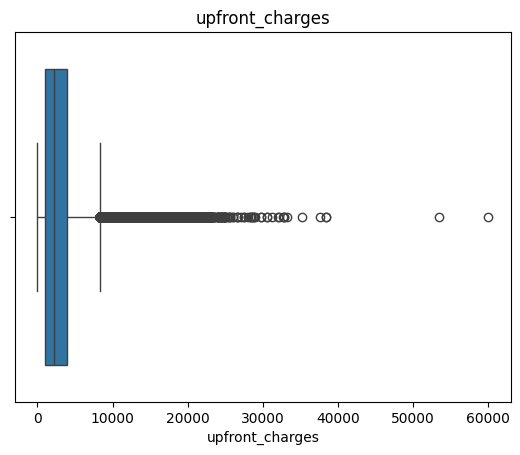

property_value: 6596 outliers


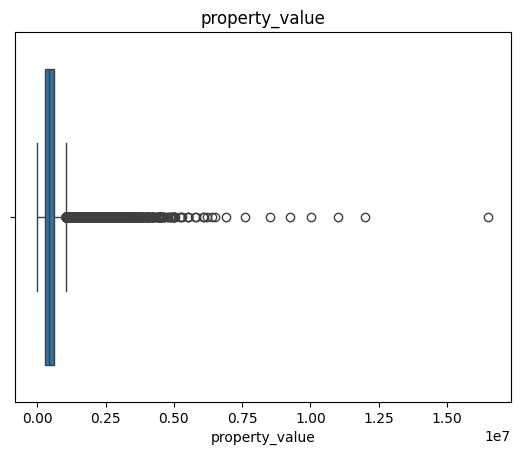

income: 7636 outliers


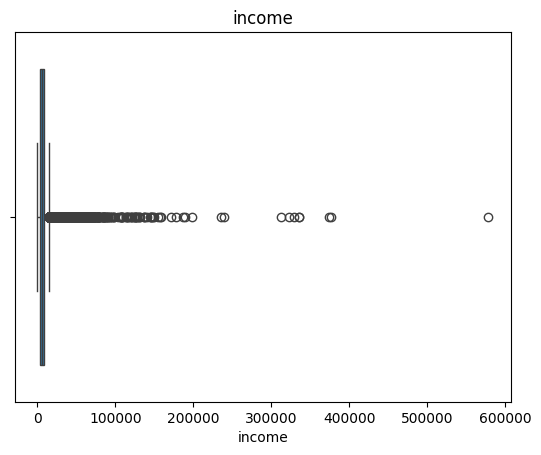

credit_score: 0 outliers


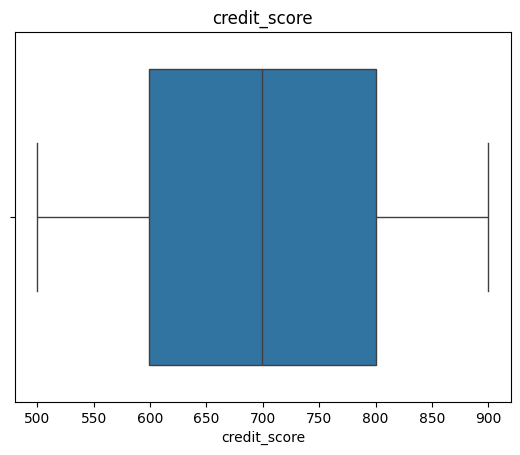

loan_to_value: 15410 outliers


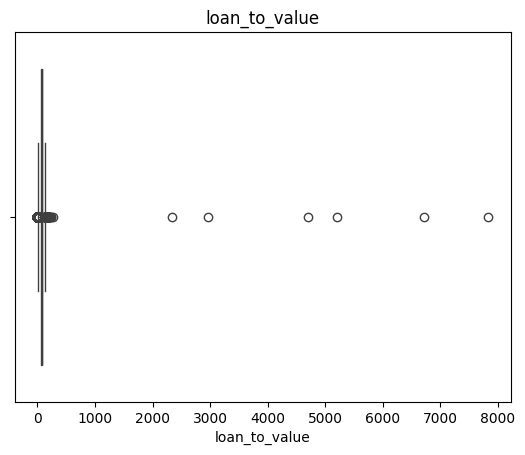

debt_to_income: 5508 outliers


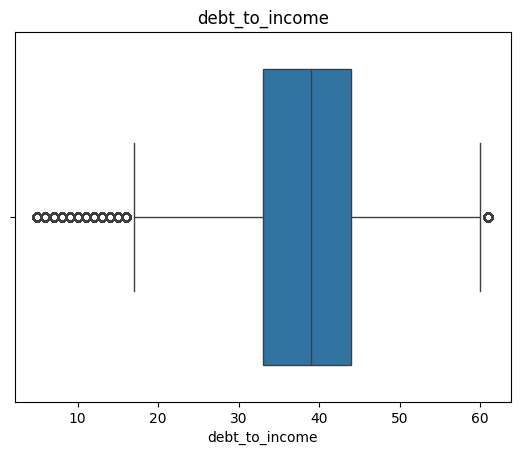

In [27]:
num_cols = loans_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['status', 'term'])

for col in num_cols:
    Q1 = loans_df[col].quantile(0.25)
    Q3 = loans_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = loans_df[(loans_df[col] < lower) | (loans_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
    sns.boxplot(x=loans_df[col])
    plt.title(col)
    plt.show()

In [28]:
loans_df['term_category'] = pd.cut(
    loans_df['term'],
    bins=[0, 180, 240, 360],
    labels=['Short-term', 'Medium-term', 'Long-term']
)

# Summary Statistics
The summary statistics show substantial variation across key financial variables such as loan amount, income, and property value, reflecting the diversity of borrowers in the dataset. Most features fall within realistic ranges (e.g., credit scores between 500 and 900, and debt-to-income ratios within typical lending thresholds). While some variables exhibit extreme values, this is expected in financial data and does not indicate data quality issues. Overall, the dataset appears consistent and suitable for machine learning after preprocessing.


In [29]:
loans_df.drop(columns=['status', 'term']).describe()

,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,property_value,income,credit_score,loan_to_value,debt_to_income
count,1.486700e+05,148670.000000,148670.000000,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000
mean,3.311177e+05,4.025956,0.439333,3018.666174,4.898216e+05,6883.472456,699.789103,65.438920,37.945268
std,1.839093e+05,0.497331,0.471150,2861.750144,3.420414e+05,6305.045602,115.875857,43.676572,9.664506
min,1.650000e+04,0.000000,-3.638000,0.000000,8.000000e+03,0.000000,500.000000,0.039474,5.000000
25%,1.965000e+05,3.750000,0.139900,1045.365000,2.880000e+05,3840.000000,599.000000,54.584352,33.000000
50%,2.965000e+05,3.990000,0.359900,2269.450000,4.180000e+05,5760.000000,699.000000,73.026316,39.000000
75%,4.365000e+05,4.250000,0.738800,3953.130000,5.980000e+05,8280.000000,800.000000,84.722222,44.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,1.650800e+07,578580.000000,900.000000,7831.250000,61.000000


In [30]:
loans_df = loans_df.drop(columns=['term'])  

# Checking data info
The dataset was inspected using df.info() after the cleaning process to verify data types, confirm the absence of missing values, and ensure overall consistency across all variables

In [31]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148670 entries, 24890 to 173559
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   loan_limit                 148670 non-null  object  
 1   gender                     148670 non-null  object  
 2   approv_in_adv              148670 non-null  object  
 3   loan_type                  148670 non-null  object  
 4   loan_purpose               148670 non-null  object  
 5   credit_worthiness          148670 non-null  object  
 6   open_credit                148670 non-null  object  
 7   business_or_commercial     148670 non-null  object  
 8   loan_amount                148670 non-null  int64   
 9   rate_of_interest           148670 non-null  float64 
 10  interest_rate_spread       148670 non-null  float64 
 11  upfront_charges            148670 non-null  float64 
 12  neg_ammortization          148670 non-null  object  
 13  interest_only  

# Final ML-Ready Loan Default Dataset Export

The cleaned and preprocessed dataset was saved in CSV format, ensuring it is structured, consistent, and ready for machine learning modeling.

In [32]:
loans_df.to_csv('ML_loans.csv', index=True)